<b>PARTIE A : <b> <a>  NETTOYAGE DES DONNEES  

Cette partie consiste à nettoyer et préparer le dataset avant la réalisation de l'analyse exploiratoire des données. 

Un nettoyage des données assure la qualité des données, améliore la performance des modèles et previent les erreurs durant l'analyse.

<b>A .1/ <b> <a>  Importation des librairies necessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

<b> A . 2/ <b> <a>  Chargement du jeu de données

In [2]:
# Le chemin de mon repertoire de travail

import os
os.chdir(r"C:\Users\hp\OneDrive\Bureau\Prediction_price_maison")

In [3]:
df=pd.read_csv("Data/1_Data_raw/house_price_prediction.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


<b> A . 3 /<a>  Les informations sur le dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


- <b> A . 4 /<a> Vérification des valeurs manquantes

In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

D'aprés les informations ci-dessus, le jeu de données ne contient pas de valeurs manquantes.

<b> A . 5 /<a> Vérification des doublons

In [6]:
df.duplicated().sum()

0

Aucun doublon n'a été detecté.

<b> A . 6 /<a> Vérification du type des données

In [7]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Le jeu de données est constitué de deux types de données : object et entier

<b> A . 7 / <a>Cleaning summary

Les étapes suivantes étaient réalisées dans la partie A:

- Les informations sur les variables

- vérification  des valeurs manquantes

- vérification des doublons

- vérification du type des données

Le jeu de données est maintenant prete pour l'analyse exploiratoire des données.

---------------------------------------------------------------------------------

<b>PARTIE B : <b> <a>  ANALYSE EXPLOIRATOIRE DES DONNEES  

<b> B . 1 /<a> Introduction

L'objectif de cette est : d'explorer le dataset néttoyé, comprendre les données, decouvrir les tendances cachées, 

identifier les patterns, detecter les relations entre les variables, interpréter les résultats et produire des recommandations metier.

<b> B . 2 /<a> Analyse descritive

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Le jeu de données contient **545 observations** pour chacune des variables, ce qui indique qu'il n'y a pas de valeurs manquantes pour ces variables.

- **Prix** (price) : le prix moyen est de **4,77 millions de dollars**, avec une médiane de **4,34 millions de dollars**. Les prix varient de **1,75 million à 13,30 millions**. L'écart entre la moyenne et la médiane ainsi que la valeur maximale relativement élevée suggèrent une distribution asymétrique à droite, avec la présence possible de valeurs élevées.
- **Superficie** (area) : la superficie moyenne est de **5 150,54 m²**, contre une médiane de **4 600 m²**. Elle varie de **1 650** à **16 200**. La moyenne supérieure à la médiane et l'écart important entre le minimum et le maximum suggèrent également une asymétrie à droite et une dispersion relativement importante.
- **Nombre de chambres** (bedrooms) : le nombre moyen de chambres est d'environ **2,97**, tandis que la médiane est de **3**. Les logements possèdent entre **1** et **6 chambres**. La proximité entre la moyenne et la médiane indique une distribution relativement centrée autour de **3 chambres**.
- **Nombre de salles de bain** (bathrooms) : la moyenne est de **1,29** et la médiane est de **1**. Les valeurs vont de **1** à **4 salles de bain**. La majorité des logements semblent donc disposer d'environ **1** à **2** salles de bain.
- **Nombre d'étages** (stories) : la moyenne est de **1,81 étage**, avec une médiane de *2*. Les logements comportent entre 1 et 4 étages. La valeur médiane de **2** indique qu'au moins la moitié des logements ont **2 étages** ou moins.
- **Nombre de places de parking** (parking) : la moyenne est de **0,69** place, tandis que la médiane est de **0**. Les valeurs vont de **0** à **3 places**. Cela indique qu'une part importante des logements ne dispose pas de parking, tandis que certains logements disposent de plusieurs places.

<b> B . 3 /<a>  Analyse univariée

B . 3.1 / Histogramme du prix des logements

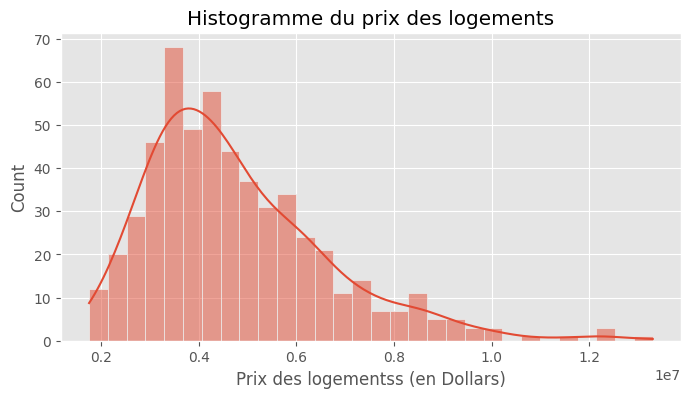

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(data=df,x="price",bins=30,kde=True)
plt.title("Histogramme du prix des logements")
plt.xlabel("Prix des logementss (en Dollars)")
plt.show()

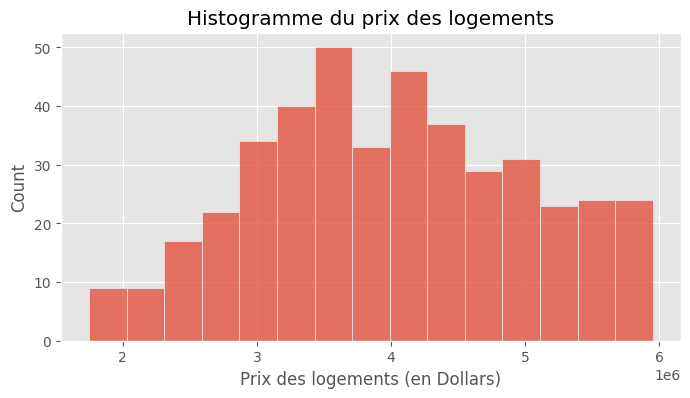

In [10]:
# FILTRE DE L'HISTOGRAMME POUR LES PRIX < 6 000 000 DOLLARS.

plt.figure(figsize=(8,4))
sns.histplot(data=df[df["price"] < 6000000],x="price",bins=15)
plt.title("Histogramme du prix des logements")
plt.xlabel("Prix des logements (en Dollars)")
plt.show()

D'après l'histogramme, la majorité des logements se vendent entre **3** et **5 millions de dollars**. 

B . 3. 2 / Boxplot du prix des logements

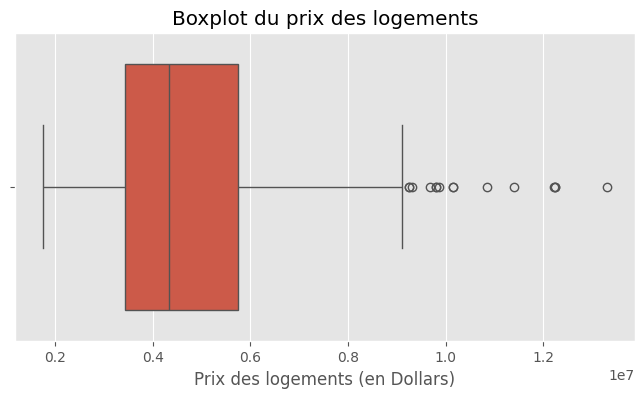

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="price")
plt.title("Boxplot du prix des logements")
plt.xlabel("Prix des logements (en Dollars)")
plt.show()


Le boxplot met en évidence la présence de plusieurs valeurs atypiques élevées, indiquant que certains logements sont vendus à des prix nettement supérieurs à ceux de la majorité. Ces prix varient de **9** à **13,3 millions de dollars**.

In [12]:
#Q1=df["price"].quantile(0.25)
#Q3=df["price"].quantile(0.75)
#IQR=Q3-Q1
#borne_sup=Q3+1.5*IQR
#borne_sup

B . 3. 3 / Histogramme de la superficie des logements

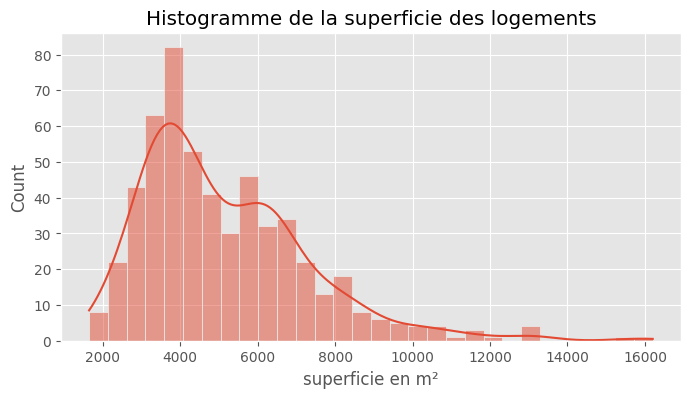

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(data=df,x="area",kde=True, bins=30)
plt.title("Histogramme de la superficie des logements")
plt.xlabel("superficie en m²")
plt.show()

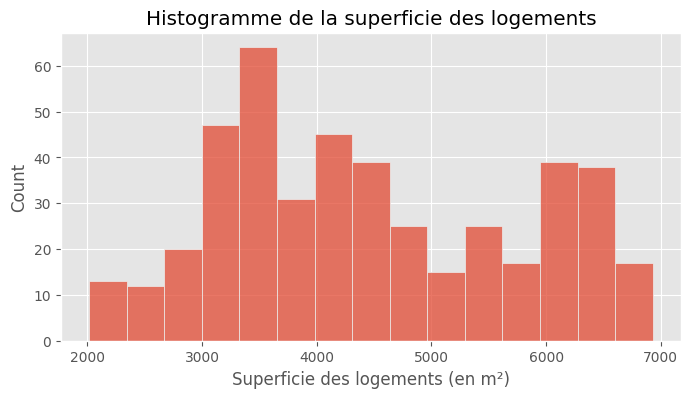

In [14]:
# FILTRE DE L'HISTOGRAMME POUR LES SUPERFICIES ENTRE 2 000 ET 7 000 m2.

plt.figure(figsize=(8,4))
sns.histplot(data=df[(df["area"] > 2000) & (df["area"] < 7000)],x="area",bins=15)
plt.title("Histogramme de la superficie des logements")
plt.xlabel("Superficie des logements (en m²)")
plt.show()

L'histogramme montre que les logements dont la superficie est comprise entre **3 000** et **6500 m²** sont les plus représentés dans le jeu de données. 

B . 3 . 4 / Boxplot de la superficie des logements

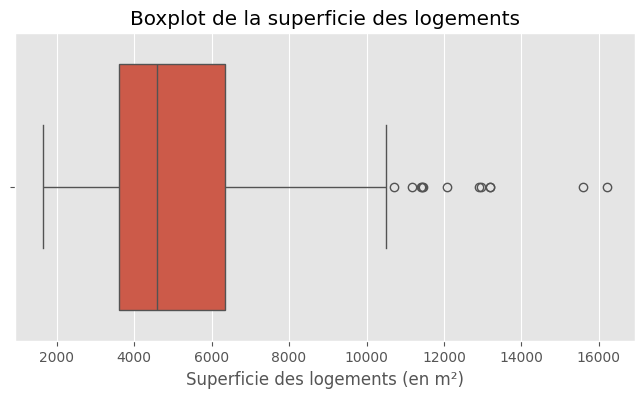

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="area")
plt.title("Boxplot de la superficie des logements")
plt.xlabel("Superficie des logements (en m²)")
plt.show()

Le boxplot met en évidence la présence de plusieurs valeurs atypiques élevées, correspondant à des logements dont la superficie est nettement supérieure à celle de la majorité des observations. Ces valeurs élevées varient de **10500** à **16200 m²**.

B .3 . 5 / Répartition des logements par statuts d'ameublement

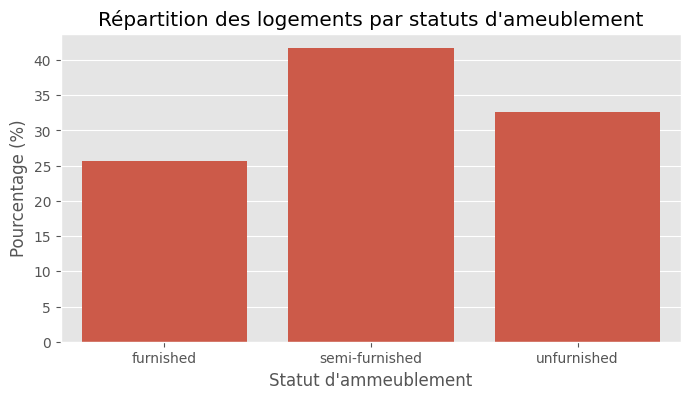

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="furnishingstatus", stat="percent")
plt.title("Répartition des logements par statuts d'ameublement")
plt.xlabel("Statut d'ammeublement")
plt.ylabel("Pourcentage (%)")
plt.show()

Un peu plus de **40 %** des logements ont un statut d'ammeublement semi-furnished, près de **35 %** avec un statut d'ammeublement unfunished et le reste des logements avec un statut furnished.

B . 3 . 5 / Répartition des logements par salle de bain

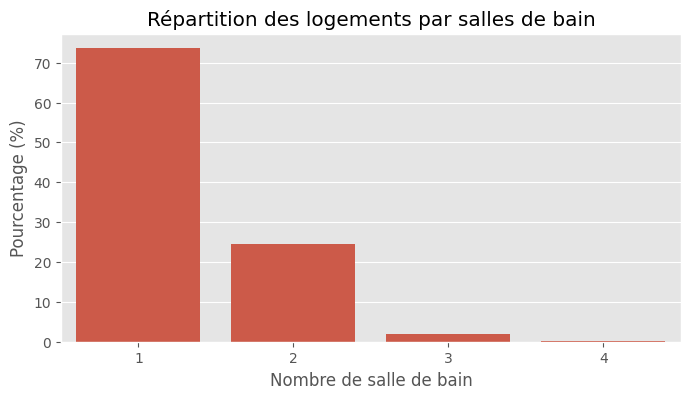

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="bathrooms",stat="percent")
plt.title("Répartition des logements par salles de bain")
plt.xlabel("Nombre de salle de bain")
plt.ylabel("Pourcentage (%)")
plt.show()

Le graphique confirme que la majorité des logements dispose de **1** ou **2 salle de bain**.

B . 3 . 6 / Répartition prefarea

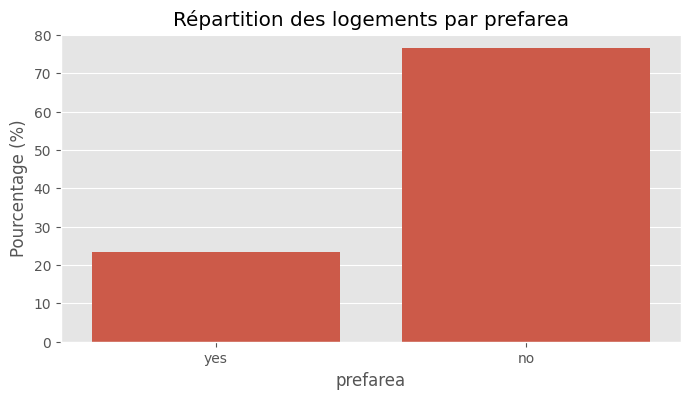

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="prefarea",stat="percent")
plt.title("Répartition des logements par prefarea")
plt.ylabel("Pourcentage (%)")
plt.show()

Seulement pres de **25 %** des logements se situent dans des endroits très prisé, recherché ou haut de gamme de la ville.

B . 3 . 7 / Répartition hotwaterheating

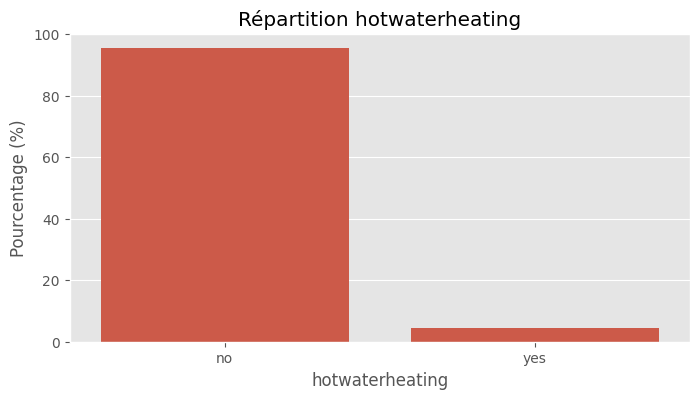

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="hotwaterheating",stat="percent")
plt.title("Répartition hotwaterheating")
plt.ylabel("Pourcentage (%)")
plt.show()

Presque tous les logements disposent d'un systeme de chauffage.

B . 3 . 8 / Répartition airconditioning

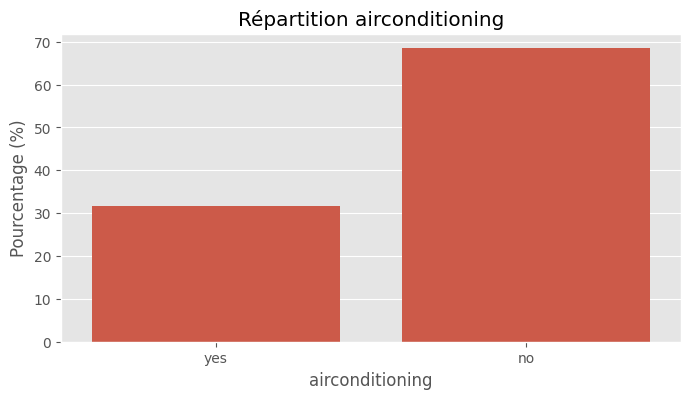

In [20]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="airconditioning",stat="percent")
plt.title("Répartition airconditioning")
plt.ylabel("Pourcentage (%)")
plt.show()

Seulement près de **30 %** des logements sont équipés d'un systeme de climatisation.

B . 3 . 9 / Répartition mainroad

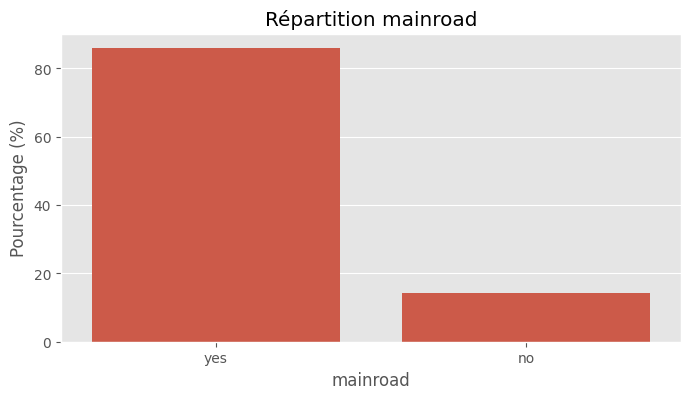

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x="mainroad",stat="percent")
plt.title("Répartition mainroad")
plt.ylabel("Pourcentage (%)")
plt.show()

Un peu plus de **80 %** des logements sont reliés ou situés sur une route principale.

<b> B . 4 /<a> Analyse bivariée

B . 4 . 1 / Boxplot du prix des logements en fonction du prefarea

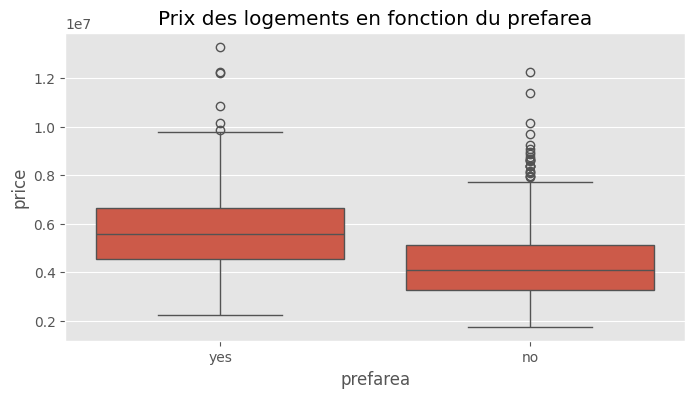

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="prefarea",y="price")
plt.title("Prix des logements en fonction du prefarea")
plt.xlabel("prefarea")
plt.show()

Les logements situés dans une zone (prefarea = yes) ont un prix médian d'environ **5,6 millions**.
Les logements situés dans une zone (prefarea = no) ont un prix médian d'environ **4,1 millions**.
La distribution des prix est donc globalement plus élevée pour les logements situés dans les zones (prefarea = yes).

B . 4 . 2 / Nuage de points du prix des logements et la superficie

Text(0.5, 1.0, 'Prix des logements en fonction de la superficie')

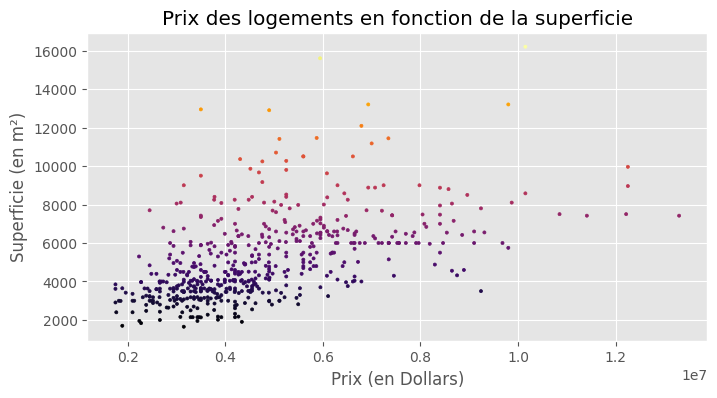

In [23]:
plt.figure(figsize=(8,4))
plt.scatter(data=df,x="price",y="area",c="area",s=5,cmap="inferno")
plt.xlabel("Prix (en Dollars)")
plt.ylabel("Superficie (en m²)")
plt.title("Prix des logements en fonction de la superficie")

Les logements avec une superficie plus grande ont tendance à avoir un prix plus élevé. Cependant, il y a des exceptions où certains logements avec une superficie plus petite ont un prix plus élevé que ceux avec une superficie plus grande. Cela peut être dû à d'autres facteurs tels que l'emplacement, les caractéristiques de la maison, etc.

B . 4 . 3 / Boxplot du prix des logements en fonction du nombre de chambres

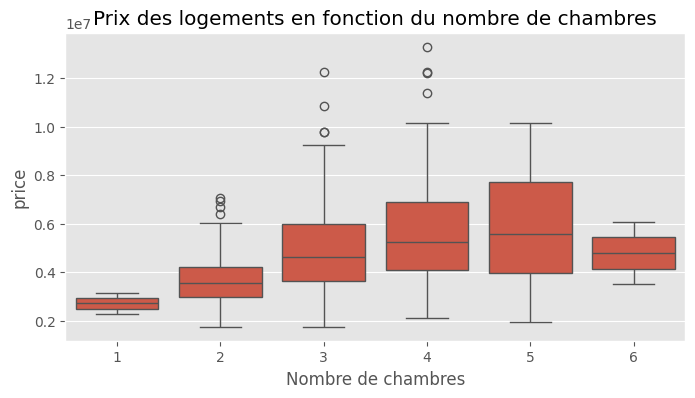

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="bedrooms",y="price")
plt.title("Prix des logements en fonction du nombre de chambres")
plt.xlabel("Nombre de chambres")
plt.show()

On observe une tendance générale à l'augmentation du prix médian lorsque le nombre de chambres augmente, surtout entre 1 et 5 chambres :

1 chambre : prix médian d'environ 2,7 millions.
2 chambres : environ 3,5 millions.
3 chambres : environ 4,6 millions.
4 chambres : environ 5,2 millions.
5 chambres : environ 5,5 millions, avec une dispersion importante.
6 chambres : le prix médian est légèrement inférieur à celui des logements de 5 chambres, autour de 4,8 millions.

La représentation des logements en fonction du nombre de chambres, met en évidence une relation globalement positive entre le nombre de chambres et le prix des logements. Le prix médian augmente progressivement de 1 à 5 chambres, passant d'environ 2,7 millions à 5,5 millions. Toutefois, cette tendance n'est pas strictement croissante, puisque les logements de 6 chambres présentent un prix médian inférieur à ceux de 5 chambres. Ces résultats suggèrent que le nombre de chambres pourrait être associé au prix des logements.

B . 4 . 4 / Boxplot du prix des logements en fonction du nombre de salles de bain

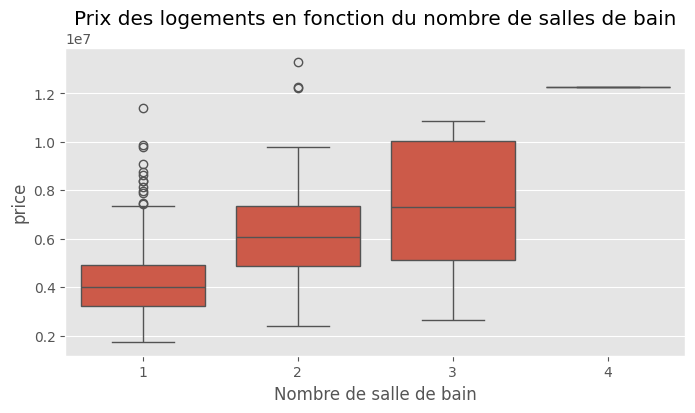

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="bathrooms",y="price")
plt.title("Prix des logements en fonction du nombre de salles de bain")
plt.xlabel("Nombre de salle de bain")
plt.show()

Une relation globalement positive entre le nombre de salles de bain et le prix des logements. Le prix médian augmente progressivement de 1 à 4 chambres. Ces résultats suggèrent que le nombre de salle de bain pourrait être associé au prix des logements.

B . 4 . 5 / Boxplot du prix des logements en fonction du statut d'ammeublement

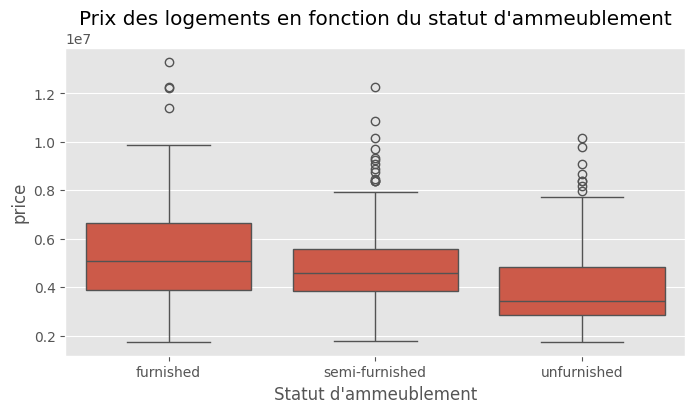

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x="furnishingstatus",y="price")
plt.title("Prix des logements en fonction du statut d'ammeublement")
plt.xlabel("Statut d'ammeublement")
plt.show()

Furnished      : prix médian d'environ **5 millions**.

Semi-furnished : environ **4,5 millions**.

Unfurnished    : environ **3,4 millions**.

Les prix ont tendance à augmenter avec le statut d'ammeublement.

<b> B . 5 /<a>  Analyse multivariée

B . 5 . 1 / Relation entre les variables numériques

<Axes: >

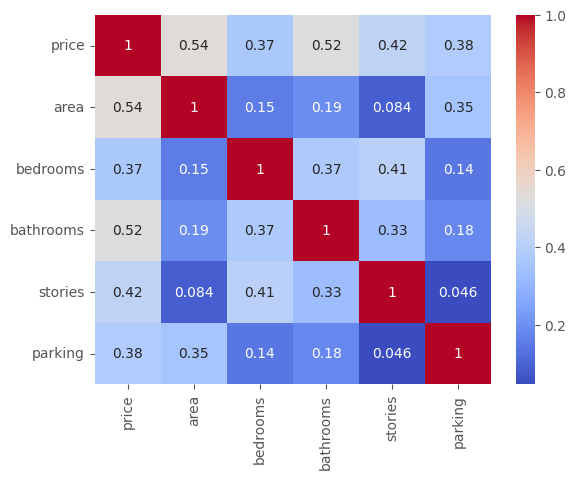

In [27]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True, cmap="coolwarm")

- Interprétation des corrélations avec le prix :

La variable **superficie** (area) présente la plus forte corrélation avec le **prix** (price), avec un coefficient de **0,54**. Il s'agit d'une corrélation positive modérée : les logements de plus grande superficie ont généralement tendance à être plus chers.

La variable **bathrooms** présente également une corrélation positive modérée avec le **prix** (**r = 0,52**). Ainsi, les logements disposant de davantage de salles de bain tendent à avoir des prix plus élevés.

Les variables **stories (r = 0,42)**, **parking (r = 0,38)** et **bedrooms (r = 0,37)** présentent des corrélations positives mais plus faibles avec le prix. Elles semblent donc également associées au prix, mais leur relation linéaire est moins importante que celle de la superficie et du nombre de salles de bain.

- Corrélations entre les variables explicatives :

On observe notamment une corrélation positive entre **bedrooms** et **stories (r = 0,41)** ainsi qu'entre **bedrooms** et **bathrooms (r = 0,37)**. Cela signifie que les logements comportant davantage de chambres ont généralement aussi davantage d'étages ou de salles de bain.

La corrélation entre **area** et **parking** est également positive **(r = 0,35)**, indiquant que les logements de plus grande superficie ont tendance à disposer de davantage de places de parking.

À l'inverse, certaines relations sont très faibles, notamment entre **stories** et **parking (r = 0,05)** et entre **area** et **stories (r = 0,08)**, ce qui indique une faible relation linéaire entre ces variables.

<b> B . 6 /<a>  Synthese des parties A et B

L'analyse descriptive porte sur **545 observations** et ne révèle aucune valeur manquante pour les variables étudiées. Les prix et les superficies présentent une forte dispersion et semblent asymétriques à droite, avec des valeurs maximales nettement supérieures aux valeurs centrales. Les logements possèdent en moyenne près de **3 chambres**, **1,29 salle de bain** et **1,81 étage**. Le nombre de places de parking est relativement faible, avec une médiane de **0**, indiquant que de nombreux logements ne disposent pas de parking.

La majorité des logements se vendent entre **3** et **5 millions de dollars**. Cependant, certains logements sont vendus à des prix nettement supérieurs à ceux de la majorité. Ces prix varient de **9** à **13,3 millions de dollars**.

Les logements dont la superficie est comprise entre **3 000** et **6500 m²** sont les plus représentés dans le jeu de données. Toutefois, des logements dont la superficie est nettement supérieure à celle de la majorité des observations, ont été constaté. Ces valeurs élevées varient de **10500** à **16200 m²**.

Seulement près de **25 %** des logements se situent dans des endroits très prisé, recherché ou haut de gamme de la ville.

Presque tous les logements disposent d'un systeme de chauffage. Cependant, seulement près de **30 %** sont équipés d'un systeme de climatisation.

Un peu plus de **80 %** des logements sont reliés ou situés sur une route principale.

Les logements situés dans une zone (prefarea = yes) ont un prix médian d'environ **5,6 millions**.
Les logements situés dans une zone (prefarea = no) ont un prix médian d'environ **4,1 millions**.
La distribution des prix est donc globalement plus élevée pour les logements situés dans les zones (prefarea = yes).

Les logements avec une superficie plus grande ont tendance à avoir un prix plus élevé. Cependant, il y a des exceptions où certains logements avec une superficie plus petite ont un prix plus élevé que ceux avec une superficie plus grande. Cela peut être dû à d'autres facteurs tels que l'emplacement, les caractéristiques de la maison, etc.

Le boxplot met en évidence une relation globalement positive entre le nombre de chambres et le prix des logements. Le prix médian augmente progressivement de **1** à **5 chambres**, passant d'environ **2,7 millions** à **5,5 millions**. Toutefois, cette tendance n'est pas strictement croissante, puisque les logements de 6 chambres présentent un prix médian inférieur à ceux de **5 chambres**. Ces résultats suggèrent que le nombre de chambres pourrait être associé au prix des logements.

De meme le nombre de salles de bain et le statut d'ammeublement pourraient être associé au prix des logements.

Globalement, d'aprés la matrice de corrélation, le prix des logements présente principalement une relation positive avec la superficie et le nombre de salles de bain. Les autres caractéristiques présentent également des corrélations positives avec le prix, mais de moindre intensité



---------------------------------------------

<b>PARTIE C : <b> <a>  FEATURE INGENIERING  

<b> C . 1 /<a> Introduction

Cette partie consiste à préparer le dataset pour le machine learning : encodage des variables categorielles, 

normalisation des variables numerique, et creation d'un preprocessing pipeline reutilisable.

In [28]:
# Liste pour stocker les indices des lignes contenant des outliers
indices_outliers=[] 

# Parcours des variables numeriques
for col in df.select_dtypes(include="number").columns:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    borne_inf=Q1-1.5*IQR
    borne_sup=Q3+1.5*IQR

    # Recuperer les indices des outliers
    indices= df[(df[col] < borne_inf) | (df[col] > borne_sup) ].index

    # Ajouter les indices dans la liste
    indices_outliers.extend(indices)

# Supprimer les doublons d'indices
indices_outliers=list(set(indices_outliers))

# Tableau contenant uniquement les outliers
df_outliers=df.loc[indices_outliers]

# Tableau sans les outliers
df_sans_outliers=df.drop(indices_outliers)


Dataset des outliers

In [29]:
display(df_outliers.head(3))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


Dataset sans les outliers

In [30]:
display(df_sans_outliers.head(3))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished


In [31]:
df_sans_outliers.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished
20,8750000,4320,3,1,2,yes,no,yes,yes,no,2,no,semi-furnished


<b> C . 2 /<a> Identification des variables

In [32]:
categorical_vars=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]
numerical_vars=["area","bedrooms","bathrooms","stories","parking"]
cible_vars=["price"]

<b> C . 3 /<a> Encodage des variables categorielles

C . 3 .1 / Creation de la fonction onehot encoder

In [ ]:
def one_hot_encode(possible_values, x):
    """
    Fonction pour encoder one hot les variables categorielles
    """
    index = possible_values.index(x)                 # Trouve la position de la valeur x dans la liste possible_values
    vector_code = len(possible_values) * [0.]        # Crée une liste de zéros de la même longueur que possible_values
    vector_code[index] = 1.                          # Remplace la valeur à l'index correspondant par 1
    return vector_code                               # Retourne le vecteur codé


# EXEMPLE
# possible_values = ["rouge", "vert", "bleu"]
# x = "vert"

# one_hot_encode(possible_values, x)
# va faire :

# index = 1 car "vert" est à l'indice 1.
# vector_code = [0.0, 0.0, 0.0]
# vector_code[1] = 1.0 → donc [0.0, 1.0, 0.0]
# La fonction retourne [0.0, 1.0, 0.0]            

# Avantages :
# C’est une représentation numérique que les modèles de machine learning peuvent utiliser.
# Elle ne suppose aucun ordre entre les catégories (contrairement à un simple encodage par nombre entier).  

C . 3 .2/ Application de la fonction sur les variables

In [34]:
df=df_sans_outliers

In [35]:
for var in categorical_vars:
    possible_values=df[var].unique().tolist()        # récupère toutes les valeurs uniques de la colonne et les mettent dans une liste, nécessaires pour créer le vecteur one-hot.
    df[var]=df[var].apply(lambda x:one_hot_encode(possible_values,x))         # Ensuite on applique one_hot_encode() à chaque valeur de la colonne.

for var in numerical_vars:
    df[var]=df[var].apply(lambda x:[x])        # But: Convertir chaque nombre en liste contenant un seul élément 
                                                                      # Pourquoi ? Pour que toutes les colonnes (catégorielles ou numériques) soient au même format (listes), ce qui permet de les concaténer facilement
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,[6000],[4],[1],[2],"[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]",[2],"[1.0, 0.0]","[1.0, 0.0, 0.0]"
16,9100000,[6600],[4],[2],[2],"[1.0, 0.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[0.0, 1.0]",[1],"[0.0, 1.0]","[0.0, 1.0, 0.0]"
18,8890000,[4600],[3],[2],[2],"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[0.0, 1.0]",[2],"[1.0, 0.0]","[0.0, 0.0, 1.0]"
19,8855000,[6420],[3],[2],[2],"[1.0, 0.0]","[1.0, 0.0]","[0.0, 1.0]","[1.0, 0.0]","[0.0, 1.0]",[1],"[0.0, 1.0]","[1.0, 0.0, 0.0]"
20,8750000,[4320],[3],[1],[2],"[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]","[0.0, 1.0]","[1.0, 0.0]",[2],"[1.0, 0.0]","[1.0, 0.0, 0.0]"


C . 3 .3 / Concantenation des variables

In [36]:
df["encoding_input"]=df["area"]+df["bedrooms"]+df["bathrooms"]+df["stories"]+df["airconditioning"]+df["mainroad"]+df["guestroom"]+df["basement"]+df["hotwaterheating"]+ df["parking"]+df["prefarea"]+df["furnishingstatus"]

df["encoding_input"].head(5)

15    [6000, 4, 1, 2, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...
16    [6600, 4, 2, 2, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...
18    [4600, 3, 2, 2, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...
19    [6420, 3, 2, 2, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...
20    [4320, 3, 1, 2, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...
Name: encoding_input, dtype: object

-----------------------------------------

<b>PARTIE D :  <a>  APPRENTISSAGE DES MODELES 

<b> D . 1 /<a> Introduction

L'objectif de cette partie est d'entrainer plusieurs modèles pour la prédiction ** Prix logement** et compare leurs performances.

Différents alguorithmes seront evalués pour identifier le modèle plus convenable pour le deployment.

<b> D . 2 /<a> Division du dataset en train et test 

In [37]:
from sklearn.model_selection import train_test_split

train_data,test_data=train_test_split(df[["price","encoding_input"]],test_size=0.2,random_state=2)

X_train=train_data["encoding_input"].values.tolist()
Y_train=train_data["price"].values.tolist()

<b> D . 3 /<a> Apprentissage du modèle LinearRegression

In [38]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
model_lr=lr.fit(X_train,Y_train)
model_lr

LinearRegression()

<b> D . 4 /<a> Apprentissage du modèle RandomForestRegressor

In [39]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
model_rfr=rfr.fit(X_train,Y_train)
model_rfr

RandomForestRegressor()

<b> D . 5 /<a> Apprentissage du modèle gradientboostingregressor

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
model_gbr=gbr.fit(X_train,Y_train)
model_gbr

GradientBoostingRegressor()

NB: en entreprise, on choisit le modele en fonction des performances et des contraintes metier, pas parcequ'il est populaire

------------------------------

<b>PARTIE E :  <a>  EVALUATION DES MODELES SUR LES DONNEES TEST

Donnees test

In [41]:
X_test=test_data["encoding_input"].values.tolist()
Y_test=test_data["price"].values.tolist()

E . 1  / La fonction d'erreur utilisée : MAE (erreur absolue moyenne)

In [42]:
def compute_prediction_errors(y_targets,y_predicted):
  
  prediction_errors=[abs(y_targets[n]-y_predicted[n]) for n in range(test_data.shape[0])]
  return prediction_errors

E . 2 / Le modèle LinearRegression

E . 2 . 1 / Les metrics de performance 

In [43]:
y_pred_lr=model_lr.predict(X_test)

In [44]:
from sklearn.metrics import r2_score

coefficient_de_determination_R2 = r2_score(Y_test,y_pred_lr)
erreur_absolue_moyenne=np.mean(compute_prediction_errors(Y_test,y_pred_lr))
ecart_type=np.std(compute_prediction_errors(Y_test,y_pred_lr))


print("coefficient_de_determination_R2 =",coefficient_de_determination_R2)
print("erreur_absolue_moyenne =",erreur_absolue_moyenne)
print("l'ecart_type =",ecart_type)

coefficient_de_determination_R2 = 0.6160590002498042
erreur_absolue_moyenne = 701237.6935822337
l'ecart_type = 648777.4894253517


E . 2 . 2 / Evolution de l'erreur du modèle

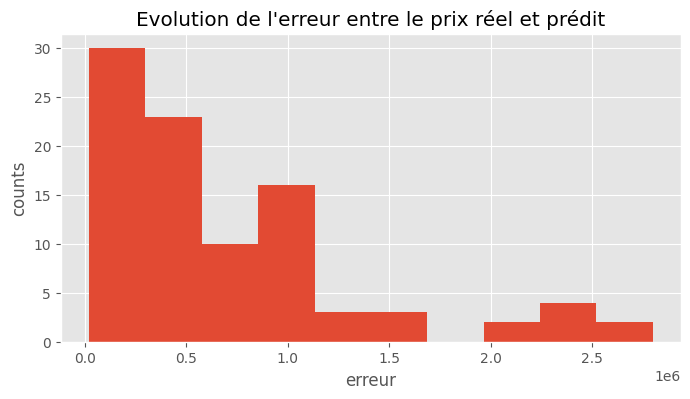

In [73]:
plt.figure(figsize=(8,4))
plt.hist(compute_prediction_errors(Y_test,y_pred_lr))
plt.xlabel('erreur')
plt.ylabel('counts')
plt.title("Evolution de l'erreur entre le prix réel et prédit")
plt.show()

E . 2 . 3 / Représentation des prix de logements reels et les prix prédit par le modèle

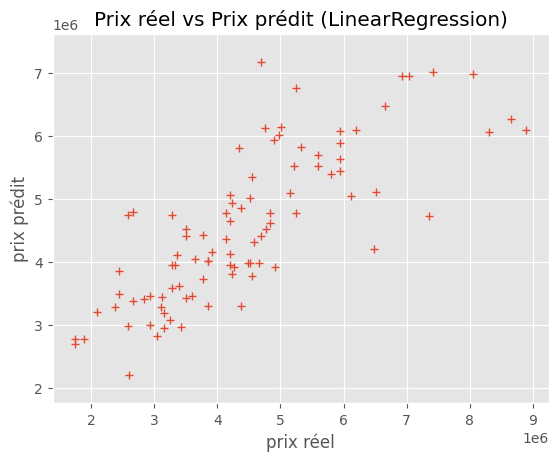

In [79]:
plt.plot(Y_test,y_pred_lr,"+")
plt.xlabel("prix réel")
plt.ylabel("prix prédit")
plt.axis("equal")
plt.title("Prix réel vs Prix prédit (LinearRegression)")
plt.grid(True)
plt.show()

E . 3 / Le modèle RandomForest

E . 3 . 1 / Les metrics de performance  du modèle

In [47]:
y_pred_rfr=model_rfr.predict(X_test)

In [48]:
from sklearn.metrics import r2_score

coefficient_de_determination_R2 = r2_score(Y_test,y_pred_rfr)
erreur_absolue_moyenne=np.mean(compute_prediction_errors(Y_test,y_pred_rfr))
ecart_type=np.std(compute_prediction_errors(Y_test,y_pred_rfr))


print("coefficient_de_determination_R2 =",coefficient_de_determination_R2)
print("erreur_absolue_moyenne =",erreur_absolue_moyenne)
print("l'ecart_type =",ecart_type)

coefficient_de_determination_R2 = 0.5114969788999368
erreur_absolue_moyenne = 784748.9444444444
l'ecart_type = 738488.0949675574


E . 3 . 2 / Evolution de l'erreur du modèle

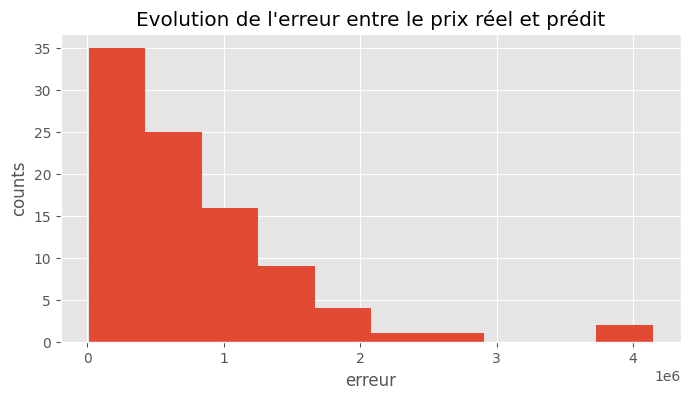

In [74]:
plt.figure(figsize=(8,4))
plt.hist(compute_prediction_errors(Y_test,y_pred_rfr))
plt.xlabel('erreur')
plt.ylabel('counts')
plt.title("Evolution de l'erreur entre le prix réel et prédit")
plt.show()

E . 3 . 3 / Représentation des prix de logements reels et les prix prédit par le modèle

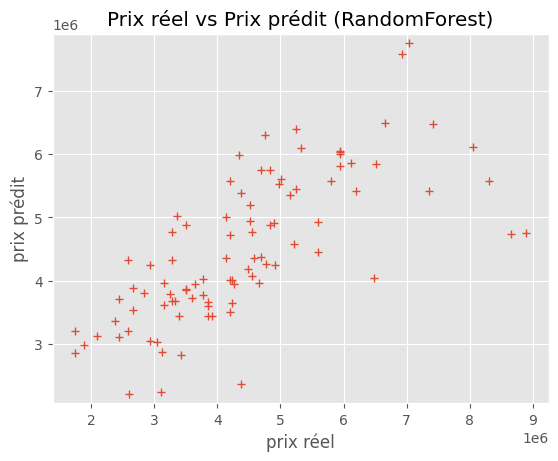

In [80]:
plt.plot(Y_test,y_pred_rfr,"+")
plt.xlabel("prix réel")
plt.ylabel("prix prédit")
plt.axis("equal")
plt.title("Prix réel vs Prix prédit (RandomForest)")
plt.grid(True)
plt.show()

E . 4 / Le modèle GradientBoosting

E . 4 . 1 / Les metrics de performance  du modèle

In [51]:
y_pred_gbr=model_gbr.predict(X_test)

In [52]:
from sklearn.metrics import r2_score

coefficient_de_determination_R2 = r2_score(Y_test,y_pred_gbr)
erreur_absolue_moyenne=np.mean(compute_prediction_errors(Y_test,y_pred_gbr))
ecart_type=np.std(compute_prediction_errors(Y_test,y_pred_gbr))


print("coefficient_de_determination_R2 =",coefficient_de_determination_R2)
print("erreur_absolue_moyenne =",erreur_absolue_moyenne)
print("l'ecart_type =",ecart_type)

coefficient_de_determination_R2 = 0.5794506433659969
erreur_absolue_moyenne = 732403.6076751245
l'ecart_type = 680625.7002611915


E . 4 . 2 / Evolution de l'erreur du modèle

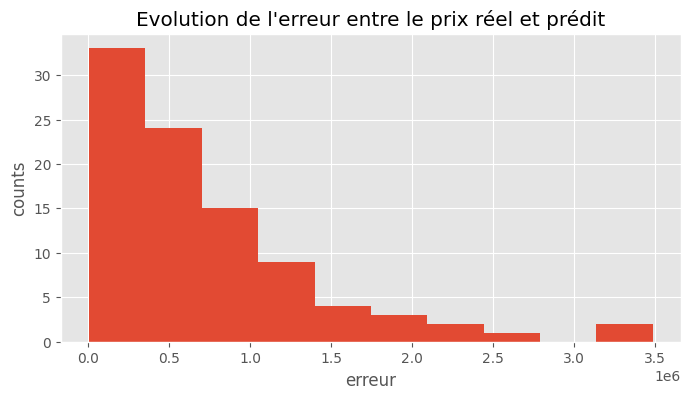

In [75]:
plt.figure(figsize=(8,4))
plt.hist(compute_prediction_errors(Y_test,y_pred_gbr))
plt.xlabel('erreur')
plt.ylabel('counts')
plt.title("Evolution de l'erreur entre le prix réel et prédit")
plt.show()

E . 4 . 3 / Représentation des prix de logements reels et les prix prédit par le modèle

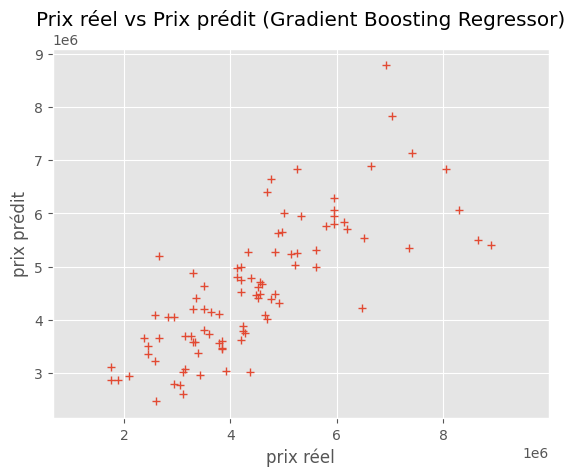

In [76]:
plt.plot(Y_test,y_pred_gbr,"+")
plt.xlabel("prix réel")
plt.ylabel("prix prédit")
plt.axis("equal")
plt.title("Prix réel vs Prix prédit (Gradient Boosting Regressor)")
plt.grid(True)
plt.show()

E . 5 / Comparaison des modèles

D'après les criteres de performances, le modèle LinearRegression enregistre la plus faible moyenne d'erreur **(701237 Dollars)** et d'ecart-type **(648777 Dollars)**. Son coefficient_de_determination_R2 **(0,62)** est plus élevé que celui des autres modèles.

<b>PARTIE F :  <a>  SAUVEGARDE DES MODELES

In [55]:
import pickle

pickle.dump(model_lr,open ("LinearRegression.sav", "wb"))

In [56]:
pickle.dump(model_rfr,open ("RandomForestRegressor.sav", "wb"))

In [57]:
pickle.dump(model_gbr,open ("GrandientBoostingRegressor.sav", "wb"))